<a href="https://colab.research.google.com/github/asmamest/Telegram-Agent/blob/main/1_Introduction_to_LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to LangGraph — The Quick Way

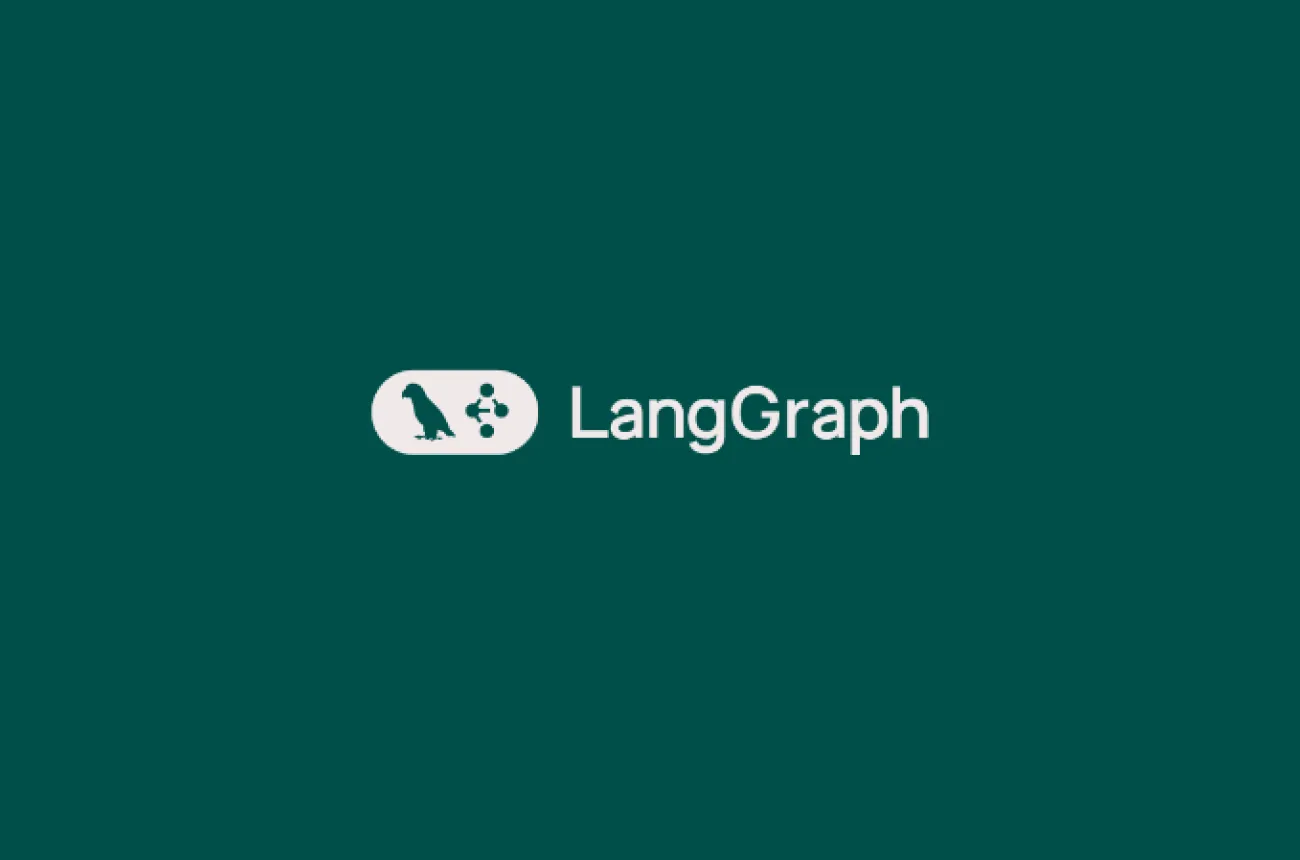

**LangGraph** is a framework built to create **advanced, stateful LLM agents and multi-agent systems**.

Instead of relying on linear pipelines, it follows a **graph-driven architecture**, giving you precise control over how agents behave — including conditional flows, tool selection strategies, loops, and shared memory.

It’s built for teams that need **reliable, scalable, and production-grade AI workflows** with **high adaptability**.

The first step is to install the **Python libraries** required for this project.

In [2]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langchain_community langgraph

# The Structure Behind LangGraph

Let’s begin by exploring LangGraph’s core components and building a basic graph.

<img src="https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dba5f465f6e9a2482ad935_simple-graph1.png" alt="Alt text" width="700"/>

**LangGraph** is built around three key elements: **state**, **nodes**, and **edges**.
Let’s start by looking at the **state**.


## 1. State


Begin by defining the **graph's State**
This state schema serves as the input structure for all **nodes** and **edges** in the graph .

In [3]:
from typing_extensions import TypedDict 

class State(TypedDict):
    graph_state: str



## 2. Nodes

**Nodes are just Python functions .**
* Each node receives the **state** as its forst argument , following the defined `TypedDict` schema .
* With a `graph_state` key in the state , nodes can access it via `state['graph_state']` .
* Each node returns an updated `graph_state` , which by default replaces the previous value in the state .



In [ ]:
def node_1(state):
    print("------- Node 1 ------")
    return {"graph_state": state['graph_state']+ "welcome  "}

def node_2(state):
    print("------ Node 2 ------")
    return {"graph_state": state['graph_state']+"to our Langgraph Crash Course !"}

def node_3(state):
    print("------- Node 3 -------")
    return {"graph_state": state['graph_state']+ " Enjoy !"}

# 3. Edges 

**Edges define how nodes are connected to the graph .**
* **Normal edges** : Always transition from one node to the next (e.g., `node_1`-> `node_2`)
* **Conditional edges** : Enables **dynamic routing** based on logic. These are functions that check the current state and return the next node to execute .


In [5]:
import random 
from typing import Literal

def decide_node(state) -> Literal["node_2","node_3"]:
    user_input = state['graph_state']

    if random.random()< 0.5 :
        return "node_2"
    return "node_3"

# 4. Graph Setup 

Now, let's build the graph using the components we've defined 
* Use the `StateGraph` class to create the graph structure 
* Initialize it with the **State schema** defined ealier 
> Add your **nodes** and connect them with **edges**
* Use the `START` **node** as the entry point for user input 
* Use the `END` **node** to mark where the graph finishes execution 
* After adding all nodes and edges , **compile** the graph to validate its structure 
> Optionally, **visualize** the graph as a **Mermaid diagram** for a clear workflow view .

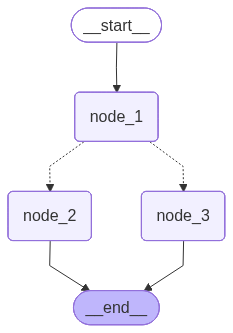

In [6]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END 

# Build graph 
builder = StateGraph(State)

# Define nodes 
builder.add_node("node_1",node_1)
builder.add_node("node_2",node_2)
builder.add_node("node_3",node_3)

# Define edges 
builder.add_edge(START,"node_1")
builder.add_conditional_edges("node_1",decide_node)
builder.add_edge("node_2",END)
builder.add_edge("node_3",END)

# Compile
graph = builder.compile()

# Visualization 
display(Image(graph.get_graph().draw_mermaid_png()))

# 5.Graph Execution 

The compiled graph follows the `Runnable` protocol, which standardizes how LangGraph components execute .
* The key method is `.invoke()`
* Pass an input dictionary (e.g., {"graph_state": "Hi there, it's Asma!"}) to set the initial state.
* Execution starts at the START **node** and moves through your defined nodes (node_1, node_2, node_3).
* **Conditional edges** determine the path dynamically (e.g., 50/50 chance between `node_2` or `node_3`).
* Each node receives the current state, updates `graph_state`, and passes it along.
* Execution continues until the END node, signaling completion.

In [7]:
graph.invoke({"graph_state": "Hi there, it's Asma !"})

------- Node 1 ------
------- Node 3 -------


{'graph_state': "Hi there, it's Asma !welcomeEnjoy !"}

***Congratulations! 🎉***
You now have a clear understanding of how LangGraph works.
Next, let’s explore the **LLM applications** you can build with this framework!

# Developing LLM Applications Using LangGraph

Our **Telegram Agent** will use a **Router** pattern, where the LLM decides which workflow to follow.

**The Router is an advanced version of static LLM Chains.**
In the next sections, we’ll see how to implement each workflow.

> Keep in mind the **Levels of Autonomy** in LLM applications! 👇

<img src="https://miro.medium.com/v2/resize:fit:2000/format:webp/1*QLhWauRsxGblZUv3JDSQdQ.png" alt="Alt text" width="700"/>

## Chains

<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/0*D-2coiGvZt5--33v" alt="Alt text" width="700"/>

Let’s create a simple chain that combines **four key concepts**:

1. Using **chat messages** as the graph state

2. Using **chat models** within graph nodes

3. **Binding tools** to our chat model

4. Executing **tool calls** inside graph nodes

# 1.Chat Messages 

Chat models can process different message types, each representing a role in the conversation. LangChain supports several key types:

* **HumanMessage** — user input

* **AIMessage** — model responses

* **SystemMessage** — instructions that guide the model

* **ToolMessage** — outputs returned by tools

We can now build a list of messages. Each message can include:

* **content** — the message text

* **name** — optional author name

* **response_metadata** — optional details from the model provider (e.g., OpenAI metadata for AIMessage)

In [ ]:
from pprint import pprint 
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=)]

### Chat Models

Chat models take a sequence of messages as input and can work with all the message types we discussed earlier.

For this project, we’ll use **OpenAI** as our chat model provider.

> Before moving on, we’ll verify that your `OPENAI_API_KEY` is set.
If not, you’ll be asked to enter it.

In [10]:
import os , getpass
def _set_env(var:str):
    if not os.environ.get(var):
        os.environ[var]= getpass.getpass(f"{var}: ")
    
_set_env("OPENAI_API_KEY")

In [11]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
result = llm.invoke(messages)

NameError: name 'messages' is not defined